 # Training Comparison for Three DRL Models (5 runs)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import rcParams
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

config = {
    "font.family": "serif",
    "font.size": 12,
    "mathtext.fontset": "stix",
    "font.serif": ["Times New Roman"],
    "axes.unicode_minus": False,
}
rcParams.update(config)


def load_reward_series(path, reward_key=None):
    record = np.load(path, allow_pickle=True).tolist()
    if reward_key is None:
        return np.asarray(record, dtype=float)
    return np.asarray(record[reward_key], dtype=float)


def lighten(color, blend=0.7):
    rgb = np.asarray(to_rgb(color), dtype=float)
    white = np.ones(3, dtype=float)
    return tuple(np.clip(rgb * (1 - blend) + white * blend, 0.0, 1.0))


def darken(color, factor=0.78):
    rgb = np.asarray(to_rgb(color), dtype=float)
    return tuple(np.clip(rgb * factor, 0.0, 1.0))
            


In [ ]:
MODEL_SPECS = [
    {
        "name": "DRL-Base",
        "run_paths": [
            Path("Results_DQN_reward3/Results/Train.npy"),
            Path("Results_DQN_reward3/Results_1/Train.npy"),
            Path("Results_DQN_reward3/Results_2/Train.npy"),
            Path("Results_DQN_reward3/Results_3/Train.npy"),
            Path("Results_DQN_reward3/Results_w/Train.npy"),
        ],
        "reward_key": "Episode_reward",
        "color": "#a1d99b",
    },
    {
        "name": "DRL-GIenv",
        "run_paths": [
            Path("Results_DQN_reward3_train_GI/Results/Train_GI.npy"),
            Path("Results_DQN_reward3_train_GI/Results_1/Train_GI.npy"),
            Path("Results_DQN_reward3_train_GI/Results_2/Train_GI.npy"),
            Path("Results_DQN_reward3_train_GI/Results_3/Train_GI.npy"),
            Path("Results_DQN_reward3_train_GI/Results_w/Train_GI.npy"),
        ],
        "reward_key": "Episode_reward",
        "color": "#31a354",
    },
    {
        "name": "DRL-GCI",
        "run_paths": [
            Path("Results_DQN_reward5/Results/Train_GI_combined_reward.npy"),
            Path("Results_DQN_reward5/Results_1/Train_GI_combined_reward.npy"),
            Path("Results_DQN_reward5/Results_2/Train_GI_combined_reward.npy"),
            Path("Results_DQN_reward5/Results_3/Train_GI_combined_reward.npy"),
            Path("Results_DQN_reward5/Results_w/Train_GI_combined_reward.npy"),
        ],
        "reward_key": None,
        "color": "#006837",
    },
]

SAVE_PATH = Path("DRL_train_all_raw_repeat_runs_band_normalized.png")

MAX_EPOCHS = 200

MODEL_SPECS
            


[{'name': 'DRL-Base',
  'run_paths': [WindowsPath('Results_DQN_reward3/Results/Train.npy'),
   WindowsPath('Results_DQN_reward3/Results_1/Train.npy'),
   WindowsPath('Results_DQN_reward3/Results_2/Train.npy'),
   WindowsPath('Results_DQN_reward3/Results_3/Train.npy'),
   WindowsPath('Results_DQN_reward3/Results_w/Train.npy')],
  'reward_key': 'Episode_reward',
  'color': '#a1d99b'},
 {'name': 'DRL-GIenv',
  'run_paths': [WindowsPath('Results_DQN_reward3_train_GI/Results/Train_GI.npy'),
   WindowsPath('Results_DQN_reward3_train_GI/Results_1/Train_GI.npy'),
   WindowsPath('Results_DQN_reward3_train_GI/Results_2/Train_GI.npy'),
   WindowsPath('Results_DQN_reward3_train_GI/Results_3/Train_GI.npy'),
   WindowsPath('Results_DQN_reward3_train_GI/Results_w/Train_GI.npy')],
  'reward_key': 'Episode_reward',
  'color': '#31a354'},
 {'name': 'DRL-GCI',
  'run_paths': [WindowsPath('Results_DQN_reward5/Results/Train_GI_combined_reward.npy'),
   WindowsPath('Results_DQN_reward5/Results_1/Train_GI_co

In [ ]:
train_rewards = {}

for spec in MODEL_SPECS:
    full_reward_runs = [
        load_reward_series(path, spec["reward_key"])
        for path in spec["run_paths"]
    ]

    global_min = min(float(series.min()) for series in full_reward_runs)
    global_max = max(float(series.max()) for series in full_reward_runs)

    if np.isclose(global_max, global_min):
        normalized_full_runs = [np.zeros_like(series, dtype=float) for series in full_reward_runs]
    else:
        normalized_full_runs = [
            (series - global_min) / (global_max - global_min)
            for series in full_reward_runs
        ]

    common_epochs = min(len(series) for series in normalized_full_runs)
    plot_epochs = common_epochs if MAX_EPOCHS is None else min(MAX_EPOCHS, common_epochs)

    reward_runs = [series[:plot_epochs] for series in normalized_full_runs]
    reward_matrix = np.vstack(reward_runs)

    train_rewards[spec["name"]] = {
        "runs": reward_runs,
        "reward_matrix": reward_matrix,
        "upper": reward_matrix.max(axis=0),
        "lower": reward_matrix.min(axis=0),
        "epochs": np.arange(1, plot_epochs + 1),
        "color": spec["color"],
        "run_paths": spec["run_paths"],
        "normalization_min": global_min,
        "normalization_max": global_max,
    }

    print(
        f"{spec['name']}: plotted epochs = {plot_epochs}, "
        f"normalization min = {global_min:.4f}, max = {global_max:.4f}"
    )
    for run_idx, path in enumerate(spec["run_paths"], start=1):
        print(f"  run {run_idx}: {path}")



DRL-Base: plotted epochs = 200, normalization min = -2115.5014, max = -497.9882
  run 1: Results_DQN_reward3\Results\Train.npy
  run 2: Results_DQN_reward3\Results_1\Train.npy
  run 3: Results_DQN_reward3\Results_2\Train.npy
  run 4: Results_DQN_reward3\Results_3\Train.npy
  run 5: Results_DQN_reward3\Results_w\Train.npy
DRL-GIenv: plotted epochs = 200, normalization min = -2251.9495, max = -341.9843
  run 1: Results_DQN_reward3_train_GI\Results\Train_GI.npy
  run 2: Results_DQN_reward3_train_GI\Results_1\Train_GI.npy
  run 3: Results_DQN_reward3_train_GI\Results_2\Train_GI.npy
  run 4: Results_DQN_reward3_train_GI\Results_3\Train_GI.npy
  run 5: Results_DQN_reward3_train_GI\Results_w\Train_GI.npy
DRL-GCI: plotted epochs = 200, normalization min = -2591.7687, max = -883.1330
  run 1: Results_DQN_reward5\Results\Train_GI_combined_reward.npy
  run 2: Results_DQN_reward5\Results_1\Train_GI_combined_reward.npy
  run 3: Results_DQN_reward5\Results_2\Train_GI_combined_reward.npy
  run 4: Res

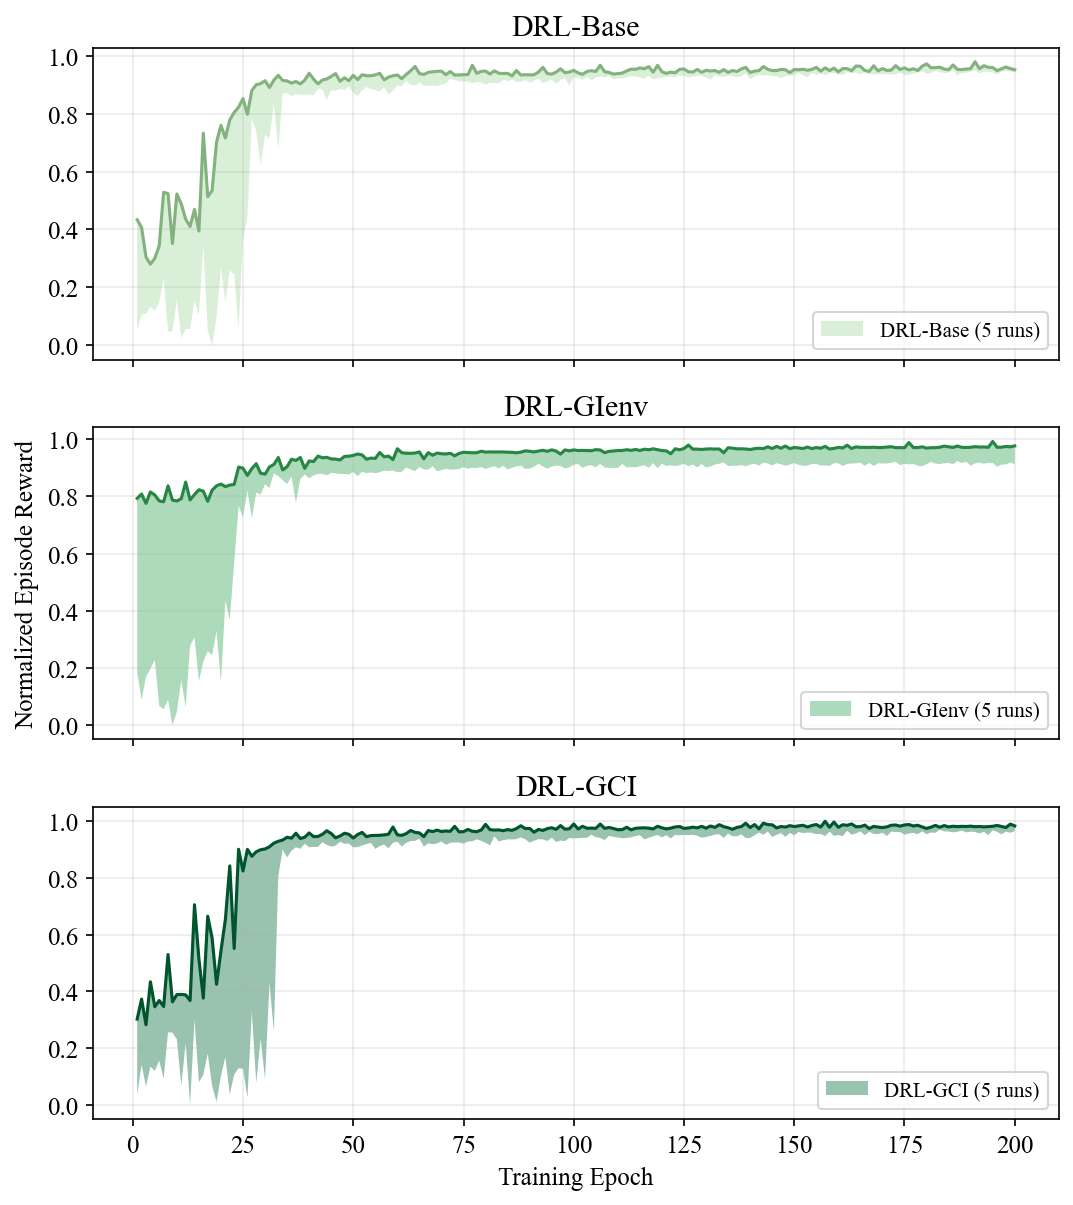

Save path: DRL_train_all_raw_repeat_runs_band_normalized.png


In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(7.4, 8.2), dpi=150, sharex=True)

for idx, spec in enumerate(MODEL_SPECS):
    series = train_rewards[spec["name"]]
    epochs = series["epochs"]
    upper = series["upper"]
    lower = series["lower"]
    color = series["color"]
    upper_color = darken(color, factor=0.82)

    ax[idx].fill_between(
        epochs,
        lower,
        upper,
        color=color,
        alpha=0.4,
        edgecolor="none",
        linewidth=0,
    )

    band_patch = Patch(
        facecolor=color,
        edgecolor="none",
        alpha=0.4,
        label=f"{spec['name']} (5 runs)",
    )

    ax[idx].plot(
        epochs,
        upper,
        linewidth=1.5,
        color=upper_color,
    )

    ax[idx].set_title(spec["name"])
    ax[idx].legend(handles=[band_patch], loc="best", fontsize=10)
    ax[idx].grid(True, alpha=0.25)

ax[1].set_ylabel("Normalized Episode Reward")
ax[2].set_xlabel("Training Epoch")

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Save path: {SAVE_PATH}")

